<a href="https://colab.research.google.com/github/robotlover2/deeplearning26.08.10/blob/main/08.11%2013_CNN_%EB%8B%A4%EC%A4%91%EB%B6%84%EB%A5%98_%ED%8F%90%EB%A0%B4%EC%BD%94%EB%A1%9C%EB%82%98%EB%B6%84%EB%A5%98_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 딥러닝 이미지 데이터 분류 모델 구현하기 (2) (학생용 실습본)
# 정상 / 폐렴 / COVID-19 다중 분류와 성능 평가

---

### 학습 목표

- 이진 분류 모델을 **3클래스 다중 분류**로 확장할 수 있다.
- 학습 곡선을 읽고 **과적합을 진단**하고, 증강·드롭아웃으로 개선할 수 있다.
- **혼동행렬 · 정밀도 · 재현율 · F1** 을 계산하고 의료 영상 관점에서 해석할 수 있다.
- 클래스 불균형이 성능 지표에 미치는 영향을 설명할 수 있다.

### 이진 vs 다중 분류 무엇이 달라지는가

| 항목 | (이진) |  (다중) |
|---|---|---|
| 클래스 | NORMAL / PNEUMONIA | NORMAL / PNEUMONIA / COVID-19 |
| 출력층 | `Dense(1, sigmoid)` | `Dense(3, softmax)` |
| 손실 함수 | `binary_crossentropy` | `categorical_crossentropy` |
| 판정 | 확률 ≥ 임계값 | 가장 확률이 높은 클래스 |

**구조는 그대로, 출력층과 손실 함수만 바뀐다.** 1일차에서 확인한 규칙이 여기서도 반복된다.

## 이 노트북 사용법 — 학생용 실습본

이 파일은 **핵심 코드가 빈칸(`____`)으로 비워진 실습본**이다.
수업 중 강사의 설명을 들으며 빈칸을 직접 채워 넣는다.

### 진행 방법

1. 코드 셀 위쪽의 **`채울 곳`** 안내 블록을 먼저 읽는다.
2. 코드 안의 `____` 를 찾아 알맞은 값·함수 이름으로 바꾼다. 각 빈칸에는 `①` `②` 번호가 붙어 있다.
3. `Shift + Enter` 로 셀을 실행한다.

### 실행하면 이런 오류가 난다면

| 오류 메시지 | 원인 |
|---|---|
| `NameError: name '____' is not defined` | 아직 채우지 않은 빈칸이 남아 있다 |
| `SyntaxError` | 빈칸을 지우면서 괄호·따옴표를 함께 지웠다 |

> 빈칸이 아닌 부분은 이미 완성되어 있으니 고치지 않아도 된다.
> 막히면 손을 들거나 채팅으로 알리자. 정답본은 수업 후 배포된다.

## 실행 환경 안내

1. `런타임` → `런타임 유형 변경` → **T4 GPU** 선택
2. 위에서부터 순서대로 실행 (`Shift + Enter`)
3. 학습에 약 3~5분이 소요된다.

---
## 1.라이브러리 가져오기

In [1]:
# 한글 폰트 지원 matplotlib
!pip install -q koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 68.1 MB/s eta 0:00:00


In [2]:
import os, zipfile
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import koreanize_matplotlib

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

tf.random.set_seed(42); np.random.seed(42)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2.데이터셋 준비

**COVID-19 Image Dataset** (Kaggle, 3클래스 흉부 X-ray)
원본: https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset

수업용으로 구글 드라이브에 미리 올려 둔 파일을 내려받는다.

In [3]:
!gdown 1bO2zJTTtSspLpLn6HdUFrVREIm2gMYxr

Downloading...
From (original): https://drive.google.com/uc?id=1bO2zJTTtSspLpLn6HdUFrVREIm2gMYxr
From (redirected): https://drive.google.com/uc?id=1bO2zJTTtSspLpLn6HdUFrVREIm2gMYxr&confirm=t&uuid=b2562f30-2a44-4f17-ae1a-ea955665be58
To: /content/covid_dataset.zip
100% 166M/166M [00:04<00:00, 39.7MB/s]


In [4]:
with zipfile.ZipFile("./covid_dataset.zip", "r") as z:
    z.extractall("./covid-19")


# 사용 할 때는 dataset 만 바꾸면 됌
TRAIN_DIR = "./covid-19/Covid19-dataset/train"
TEST_DIR  = "./covid-19/Covid19-dataset/test"

for d in [TRAIN_DIR, TEST_DIR]:
    print(f"\n[{d}]")
    for cls in sorted(os.listdir(d)):
        n = len(os.listdir(os.path.join(d, cls)))
        print(f"  {cls:12s} {n:4d}장")


[./covid-19/Covid19-dataset/train]
  Covid         111장
  Normal         70장
  Viral Pneumonia   70장

[./covid-19/Covid19-dataset/test]
  Covid          26장
  Normal         20장
  Viral Pneumonia   20장


> **먼저 확인할 것** : 클래스별 장수가 고르게 분포하는가?
> 한 클래스가 압도적으로 많으면 모델은 그 클래스만 찍어도 정확도가 높게 나온다.
> 이런 상황에서 정확도는 신뢰할 수 없는 지표가 된다.

---
## 3.데이터 확인 및 전처리

`ImageDataGenerator` 로 폴더 구조를 그대로 읽어 들인다.
폴더 이름이 곧 클래스 라벨이 된다.

```
train/
 ├── Covid/       ← 클래스 0
 ├── Normal/      ← 클래스 1
 └── Viral Pneumonia/  ← 클래스 2
```

In [5]:
# ┌─ 채울 곳 ───────────────────────────
# ① 0~255 를 0~1 로 만드는 배율 : 1/255.
# ② 학습 데이터 중 검증용 비율 : 0.2
# ③ 다중 분류에서 라벨을 원-핫으로 받는 방식 (문자열)
# └─────────────────────────────────

IMG_SIZE   = (224, 224)
BATCH_SIZE = 16

# 학습용 : 증강 + 정규화 + 검증셋 20% 분리
train_gen = ImageDataGenerator(
    rescale=1/255.,            # ①정규화 부터
    rotation_range=10,       # 촬영 각도 차이를 흉내
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2    # ② 검증셋 20% 분리
) # 학습용 객체 생성

# 검증 · 테스트용 : 정규화만 (증강하면 평가가 왜곡된다)
eval_gen = ImageDataGenerator(rescale=1/255., validation_split=0.2) # 검증용 train은 정규화만

train_ds = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", subset="training", seed=42)   # ③ 정규화 부터 증강 까지 한번에 class에 나눠서 해줌

#검증용 전체의 20%
val_ds = eval_gen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", subset="validation", seed=42, shuffle=False)

test_ds = ImageDataGenerator(rescale=1/255.).flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=1,
    class_mode="categorical", shuffle=False)

CLASS_NAMES = list(train_ds.class_indices.keys())
print("\n클래스 인덱스:", train_ds.class_indices)

Found 201 images belonging to 3 classes.
Found 50 images belonging to 3 classes.
Found 66 images belonging to 3 classes.

클래스 인덱스: {'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}


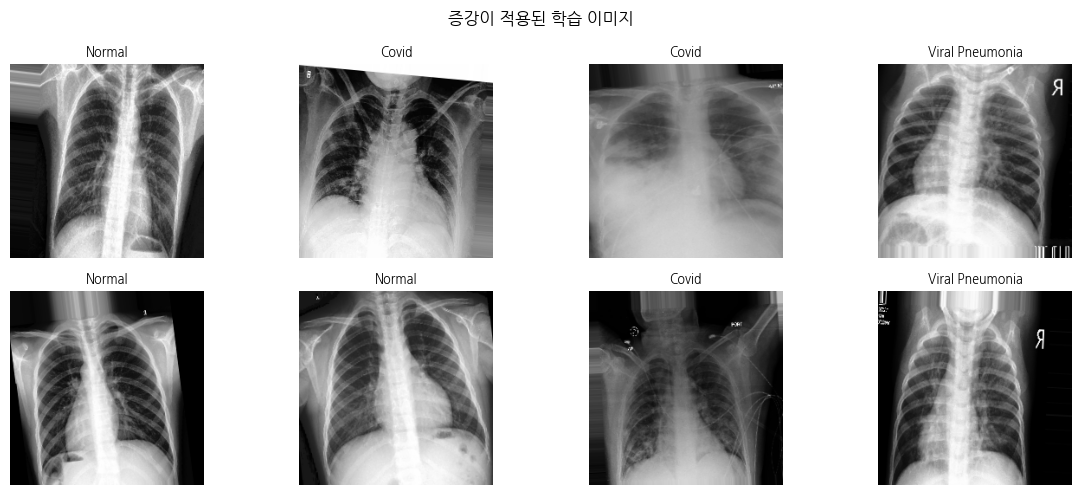

In [6]:
# 증강이 실제로 어떻게 적용되는지 눈으로 확인
imgs, labels = next(train_ds)

plt.figure(figsize=(12, 5))
for i in range(min(8, len(imgs))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(imgs[i])
    plt.title(CLASS_NAMES[labels[i].argmax()], fontsize=9)
    plt.axis("off")
plt.suptitle("증강이 적용된 학습 이미지")
plt.tight_layout(); plt.show()

---
## 4.CNN 모델 구성

전이학습을 쓰지 않고 **밑바닥부터 쌓은 CNN**이다.
10차시에서 전이학습 모델과 성능을 비교할 것이므로 결과를 기록해 둔다.

| 블록 | 구성 | 의도 |
|---|---|---|
| 1 | Conv(32) → BN → MaxPool | 선 · 모서리 등 저수준 특징 |
| 2 | Conv(64) → BN → MaxPool | 국소 패턴 조합 |
| 3 | Conv(128) → BN → MaxPool | 병변 형태 등 고수준 특징 |
| 분류부 | GAP → Dropout → Dense(3, softmax) | 클래스 확률 출력 |

`Flatten` 대신 `GlobalAveragePooling2D` 를 쓰면 파라미터가 크게 줄어 과적합에 강해진다.

In [7]:
# ┌─ 채울 곳 ─────────────────────────────
# ① Flatten 대신 쓰면 파라미터가 크게 줄어 과적합에 강한 층 이름
#    (특징맵 전체를 채널마다 평균 하나로 요약한다)
# ② 출력층 뉴런 수 : 클래스 개수를 담은 변수
# ③ 출력층 활성화 함수 : 확률 분포로 만든다
# └───────────────────────────────────

from tensorflow.keras import layers

def build_cnn(num_classes=3, input_shape=(224, 224, 3)):
    return tf.keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(), # ① 과적합이 줄어든다 파라미터의 수가 줄어들면서
        layers.Dropout(0.4),
        layers.Dense(64, activation="relu"),
        layers.Dense(3, activation='softmax'),            # ② ③
    ], name="covid_cnn")

model = build_cnn(len(CLASS_NAMES))
model.summary()

Model: "covid_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,595 (400.76 KB)

 Trainable params: 102,147 (399.01 KB)

 Non-trainable params: 448 (1.75 KB)

---
## 5.학습 설정 및 학습

In [9]:
# ┌─ 채울 곳 ────────────────────────────
# ① 손실 함수 : 라벨이 원-핫인 다중 분류용 crossentropy (문자열)
# └──────────────────────────────────

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',      # ① 다중 분류 니깐 categorical_crossentropy 사용
    metrics=["accuracy"]
)
#callback으로 earlystopping 이나 Reduce로 학습률 정체를 막음
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                         patience=4, min_lr=1e-6, verbose=1),
]

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5672 - loss: 0.8859 - val_accuracy: 0.3200 - val_loss: 1.0970 - learning_rate: 0.0010
Epoch 2/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 587ms/step - accuracy: 0.6866 - loss: 0.6377 - val_accuracy: 0.4400 - val_loss: 1.0874 - learning_rate: 0.0010
Epoch 3/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 635ms/step - accuracy: 0.6866 - loss: 0.6031 - val_accuracy: 0.4400 - val_loss: 1.2051 - learning_rate: 0.0010
Epoch 4/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 557ms/step - accuracy: 0.7313 - loss: 0.5586 - val_accuracy: 0.4400 - val_loss: 1.3184 - learning_rate: 0.0010
Epoch 5/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 645ms/step - accuracy: 0.7562 - loss: 0.5633 - val_accuracy: 0.4400 - val_loss: 1.5188 - learning_rate: 0.0010
Epoch 6/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.7794 - loss: 0.4860
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 623ms/step - accuracy: 0.8010 - loss: 0.5014 - val

---
## 6.학습 곡선 — 과적합 진단

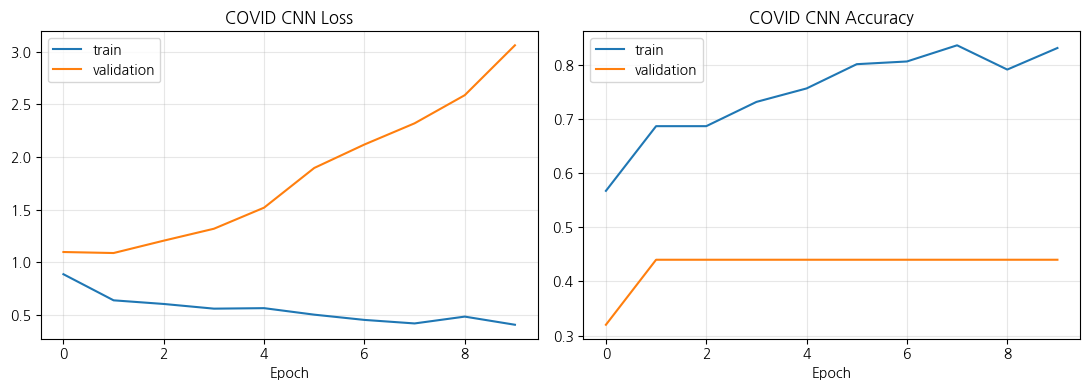

In [11]:
def plot_history(history, title="Covid"):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="validation")
    ax[0].set_title(f"{title} Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["accuracy"], label="train"); ax[1].plot(h["val_accuracy"], label="validation")
    ax[1].set_title(f"{title} Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

plot_history(history, "COVID CNN")

### 과적합 신호 세 가지

1. 학습 정확도는 계속 오르는데 **검증 정확도가 정체**한다
2. 검증 손실이 어느 시점부터 **다시 올라간다**
3. 두 곡선 사이의 **간격이 점점 벌어진다**

대응 방법 : 데이터 증강 강화 → Dropout 비율 상향 → 모델 축소 → 조기 종료.
위 코드는 이미 증강·드롭아웃·EarlyStopping을 모두 적용한 상태다.

---
## 7.성능 평가 — 정확도만 보면 안 되는 이유

In [ ]:
loss, acc = model.evaluate(test_ds, verbose=0)
print(f"테스트 정확도: {acc:.4f}  (손실 {loss:.4f})")

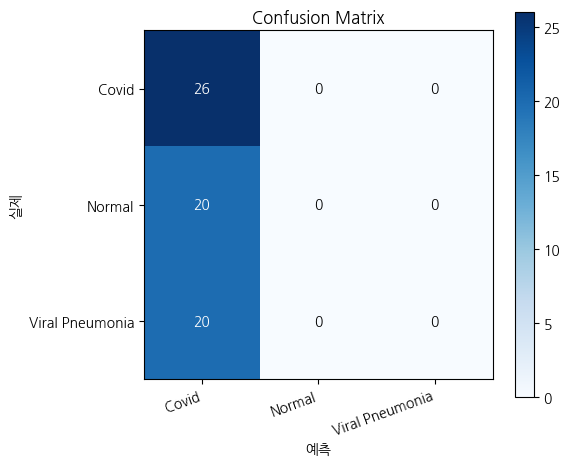

In [12]:
# ┌─ 채울 곳 ─────────────────────────
# ① 각 행에서 가장 큰 확률의 위치를 찾는다 — 어느 축인가?
# └───────────────────────────────

#test_ds.reset()  #테스트 데이터를 처음부터 다시 읽어서 전체 데이터에 대해 예측한다
y_prob = model.predict(test_ds, verbose=0)
y_pred = y_prob.argmax(axis=1)    # ①
y_true = test_ds.classes #y_true가 test에 classes에 들어간다

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues"); plt.colorbar()
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=20, ha="right")
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
plt.xlabel("예측"); plt.ylabel("실제"); plt.title("Confusion Matrix")
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout(); plt.show()

In [13]:
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

                 precision    recall  f1-score   support

          Covid      0.394     1.000     0.565        26
         Normal      0.000     0.000     0.000        20
Viral Pneumonia      0.000     0.000     0.000        20

       accuracy                          0.394        66
      macro avg      0.131     0.333     0.188        66
   weighted avg      0.155     0.394     0.223        66



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 지표 읽는 법

| 지표 | 정의 | 이 문제에서의 의미 |
|---|---|---|
| **Precision(정밀도)** | 그 클래스라고 예측한 것 중 실제로 맞은 비율 | 오진으로 인한 불필요한 격리 · 추가 검사 |
| **Recall(재현율)** | 실제 그 클래스 중 찾아낸 비율 | **놓친 환자** — 의료에서 가장 위험 |
| **F1** | 정밀도와 재현율의 조화평균 | 두 지표의 균형 |

**혼동행렬에서 가장 위험한 칸을 찾아보자.**
COVID 환자를 Normal로 예측한 칸이 그것이다. 이 칸의 값을 줄이는 것이 이 모델의 최우선 목표다.

---
## 8.예측 결과 시각화

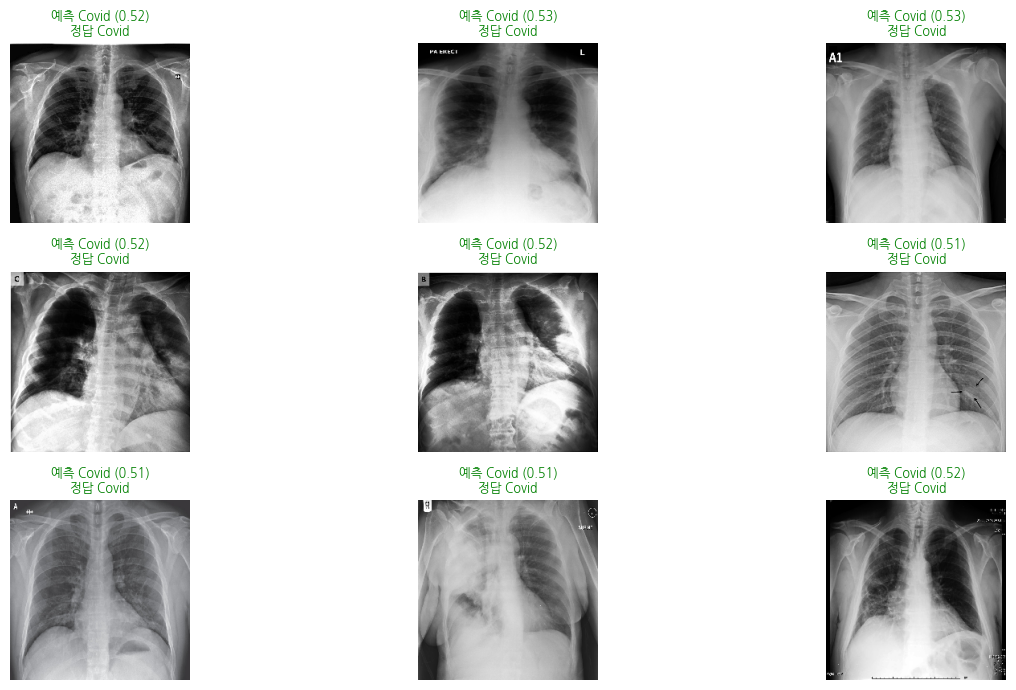

In [14]:
test_ds.reset()
plt.figure(figsize=(14, 7))
for i in range(9):
    img, lab = next(test_ds)
    p = model.predict(img, verbose=0)[0]
    true_i, pred_i = lab[0].argmax(), p.argmax()
    ok = true_i == pred_i

    plt.subplot(3, 3, i + 1)
    plt.imshow(img[0])
    plt.title(f"예측 {CLASS_NAMES[pred_i]} ({p[pred_i]:.2f})\n정답 {CLASS_NAMES[true_i]}",
              color="green" if ok else "red", fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

---
## 9.클래스별 예측 확신도 분포

모델이 **얼마나 자신 있게** 판단했는지 본다.
확신도가 0.4~0.6에 몰려 있다면 모델이 사실상 헷갈리고 있다는 뜻이다.

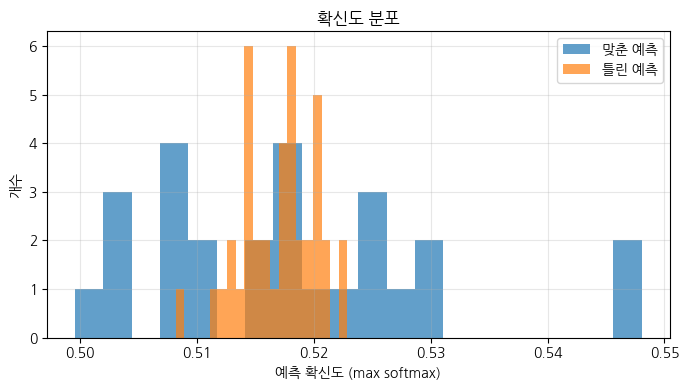

맞춘 예측 평균 확신도: 0.518
틀린 예측 평균 확신도: 0.517


In [15]:
conf = y_prob.max(axis=1)
correct = (y_pred == y_true)

plt.figure(figsize=(7, 4))
plt.hist(conf[correct],  bins=20, alpha=.7, label="맞춘 예측")
plt.hist(conf[~correct], bins=20, alpha=.7, label="틀린 예측")
plt.xlabel("예측 확신도 (max softmax)"); plt.ylabel("개수")
plt.title("확신도 분포"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"맞춘 예측 평균 확신도: {conf[correct].mean():.3f}")
if (~correct).sum():
    print(f"틀린 예측 평균 확신도: {conf[~correct].mean():.3f}")

---
## 10.모델 저장

In [16]:
model.save("covid_cnn.keras")
print("저장 완료 : covid_cnn.keras")

import json
with open("covid_classes.json", "w", encoding="utf-8") as f:
    json.dump(CLASS_NAMES, f, ensure_ascii=False)
print("클래스 정보 저장 : covid_classes.json")

저장 완료 : covid_cnn.keras
클래스 정보 저장 : covid_classes.json


---
## 11. 스스로 해보기 · 정리

| # | 실험 | 기록할 것 |
|---|---|---|
| 1 | 증강 옵션을 모두 끄고 재학습 | 검증 곡선이 얼마나 빨리 벌어지는가 |
| 2 | `Dropout(0.4)` → `0.1` | 과적합 정도 변화 |
| 3 | Conv 블록을 2개로 축소 | 파라미터 수 대비 성능 |
| 4 | `GlobalAveragePooling2D` → `Flatten` | 파라미터 수 폭증 확인 |

**기록표 (10차시 전이학습 결과와 비교)**

| 모델 | 파라미터 수 | 학습 시간 | 테스트 정확도 | COVID Recall |
|---|---|---|---|---|
| 밑바닥 CNN (이 노트북) | | | | |
| 전이학습 MobileNetV2 (10차시) | | | | |

> 데이터가 수백 장뿐일 때 밑바닥 CNN이 어디까지 갈 수 있는지 직접 확인했다.
> 다음 10차시에서는 **ImageNet으로 이미 학습된 모델**을 빌려 와 같은 문제를 다시 푼다.